# Aims of this Notebook:
- Exploratory Data Analysis
    - Check Data Formats
    - Identify Malformed Inputs
    - Trends, Patterns, Anomalies
- Plans for constructing a forecasting model for a vessel's next location
    - How the data might be transformed
    - Experimentations with input featues

# Exploratory Data Analysis

## Loading Datasets

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

In [55]:
# Read all the datasets:
port_calls = pd.read_csv("port_calls.csv")
vessels = pd.read_csv("vessels.csv")
trades = pd.read_csv("trades.csv")

In [56]:
port_calls.head()

,id,vessel_id,start_utc,end_utc,cargo_volume,draught_change,destination,destination_longitude,destination_latitude
0,366999220,74064,2023-01-01 00:00:36.000,2023-01-01 16:02:18.000,111617,5.5,Novorossiysk,37.813008,44.718040
1,366974831,70585,2023-01-01 00:00:48.000,2023-01-01 15:16:55.000,0,-0.2,Singapore,103.745613,1.234135
2,367187709,90771,2023-01-01 00:01:00.000,2023-01-03 00:00:00.000,0,-5.5,Philadelphia,-75.229059,39.949923
3,366902380,86336,2023-01-01 00:02:19.000,2023-01-03 13:37:40.000,0,-4.7,Sao Luis,-44.380646,-2.605307
4,366971646,105430,2023-01-01 00:02:57.000,2023-01-02 01:31:40.000,0,-2.0,Ulsan,129.332479,35.479874


In [57]:
vessels.head()

,id,status,status_detail,build_country,build_year,flag_name,dead_weight,vessel_type
0,80439,Active,In Service/Commission,China,2010.0,Marshall Islands,156717,Crude/Oil Products Tanker
1,114128,Active,In Service/Commission,Japan,1998.0,Sierra Leone,5790,Products Tanker
2,70991,Active,In Service/Commission,United States of America,2004.0,United States of America,141740,Crude/Oil Products Tanker
3,83934,Active,In Service/Commission,South Korea,2011.0,Greece,319861,Crude Oil Tanker
4,79383,Active,In Service/Commission,South Korea,2008.0,Malta,50344,Crude/Oil Products Tanker


In [58]:
trades.head()

,id,port_call_origin_id,port_call_destination_id,traded_volume,distance,start_date_time,end_date_time,product,product_family
0,19953452,370515046,370587079.0,260.0,1342175.0,2023-11-01 17:10:00.000,2023-11-08 12:30:00.000,palm fatty acid distillate,chem/bio
1,19322180,370515046,370634751.0,4551.0,1836735.0,2023-11-01 17:10:00.000,2023-11-10 01:46:00.000,palm fatty acid distillate,chem/bio
2,19953448,370515046,370811312.0,170.0,2714319.0,2023-11-01 17:10:00.000,2023-11-20 22:53:28.000,palm fatty acid distillate,chem/bio
3,19284088,370574938,370587079.0,1658.0,1197777.0,2023-11-04 23:30:00.000,2023-11-08 12:30:00.000,used cooking oil,chem/bio
4,19339728,370739975,370811312.0,11234.0,101991.0,2023-11-18 17:35:25.000,2023-11-20 22:53:28.000,chem/bio,chem/bio


In [59]:
print("Dataset shapes:")
print("Missing port calls:", port_calls.shape)
print("Missing vessels:", vessels.shape)
print("Missing trades:", trades.shape)

Dataset shapes:
Missing port calls: (347277, 9)
Missing vessels: (8901, 8)
Missing trades: (240037, 9)


### Some Initial Thoughts
- Could be worth transforming date columns from strings into datetime objects
- Can convert some columns into categorical types - but worth seeing how many categories there are for these

## Malformed Inputs

This section involves first converting date columns, then looking for missing values, miscalculated, or impossible values

In [60]:
# Convert the date columns to datetime format
port_calls["start_utc"] = pd.to_datetime(port_calls["start_utc"])
port_calls["end_utc"] = pd.to_datetime(port_calls["end_utc"])

trades["start_date_time"] = pd.to_datetime(trades["start_date_time"])
trades["end_date_time"] = pd.to_datetime(trades["end_date_time"])

### Missing Values

#### Port Calls

In [61]:
# Missing values
print("Missing values in port_calls:")
port_calls.isnull().sum()

Missing values in port_calls:


id                           0
vessel_id                    0
start_utc                    0
end_utc                     24
cargo_volume                 0
draught_change           49271
destination                  0
destination_longitude     1018
destination_latitude      1018
dtype: int64

In [62]:
# Starting with end_utc - there are 24 rows where values are missing - worth seeing if these are missing anything else or have any common characteristics
missing_end_utc = port_calls[port_calls["end_utc"].isnull()]
missing_end_utc

,id,vessel_id,start_utc,end_utc,cargo_volume,draught_change,destination,destination_longitude,destination_latitude
22419,367213090,115267,2023-01-24 21:12:05,NaT,0,-2.0,Kaohsiung,120.334623,22.511660
50050,367498482,62621,2023-02-22 14:01:53,NaT,90794,NaN,Mumbai,72.959474,18.872354
91102,367893216,69124,2023-04-06 03:33:00,NaT,0,NaN,Chittagong,91.801556,22.054577
126285,368342536,101735,2023-05-12 09:00:00,NaT,0,NaN,Genoa,8.879961,44.412879
145494,368607998,115833,2023-06-01 09:36:55,NaT,11814,NaN,Chornomorsk,30.665153,46.315711
164383,368795374,114750,2023-06-21 11:26:53,NaT,0,0.0,Nishtun,52.203412,15.816707
187548,369270269,75766,2023-07-15 20:52:17,NaT,326360,NaN,Port Gentil,8.731685,-0.636293
196664,369412092,114266,2023-07-25 08:05:21,NaT,0,NaN,Khalifa Industrial Zone,54.675400,24.819881
215085,369653146,116735,2023-08-14 03:48:10,NaT,0,NaN,Surabaya,112.688849,-7.168280
222781,369762149,68285,2023-08-22 01:59:45,NaT,0,NaN,Himeji,134.737559,34.769154


These port calls dont seem to have much in common, aside also missing draught change - Could just be missed recordings?

Worth plotting them anyway to check for regions (harder to tell vs looking purely at lon/lat)

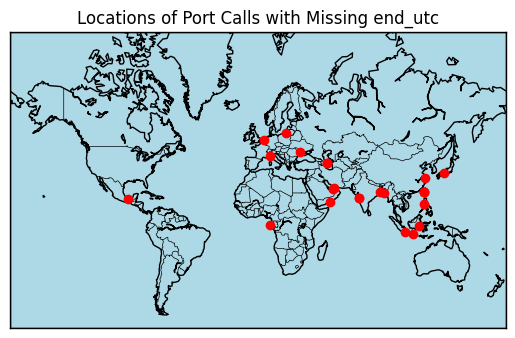

In [63]:
# Check to see how these are distributed geographically - are they all in one area or spread out?
missing_end_utc_map = Basemap(
    projection="merc",
    llcrnrlat=-60,
    urcrnrlat=80,
    llcrnrlon=-180,
    urcrnrlon=180,
    resolution="c",
)
missing_end_utc_map.drawcoastlines()
missing_end_utc_map.drawcountries()
missing_end_utc_map.drawmapboundary(fill_color="lightblue")
x, y = missing_end_utc_map(
    missing_end_utc["destination_longitude"].values,
    missing_end_utc["destination_latitude"].values,
)
missing_end_utc_map.scatter(x, y, marker="o", color="red", zorder=5)
plt.title("Locations of Port Calls with Missing end_utc")
plt.show()

Plot shows values spread mostly through Asia, with only a few outside this region - Likely some issue with recording

In [64]:
# Missing Draught Change - 49271 missing values (~14% of the dataset) - worth seeing if these are missing anything else or have any common characteristics
missing_draught_change = port_calls[port_calls["draught_change"].isnull()]
missing_draught_change

,id,vessel_id,start_utc,end_utc,cargo_volume,draught_change,destination,destination_longitude,destination_latitude
10,366603362,82485,2023-01-01 00:07:35,2023-01-02 01:00:00,12444,NaN,Kawasaki,139.752629,35.494882
11,366999241,68950,2023-01-01 00:08:53,2023-01-01 14:26:17,29310,NaN,Ulsan,129.332479,35.479874
27,368468278,69430,2023-01-01 00:33:00,2023-01-06 06:35:00,0,NaN,Caofeidian,118.497186,39.010958
31,366999245,79699,2023-01-01 00:36:00,2023-01-01 05:34:00,0,NaN,Baku,49.889961,40.343447
38,366952350,82251,2023-01-01 00:52:15,2023-01-01 23:57:01,5625,NaN,Bordeaux,-0.597965,45.046788
...,...,...,...,...,...,...,...,...,...
347233,371324045,72634,2023-12-31 22:38:10,2024-01-01 23:45:03,28708,NaN,Constanta Light.,28.994348,43.987877
347234,371324044,71444,2023-12-31 22:38:10,2024-01-01 23:45:03,51803,NaN,Constanta Light.,28.994348,43.987877
347272,371325310,72072,2023-12-31 23:56:57,2024-01-01 03:37:33,6845,NaN,Kerch Light.,36.565590,45.105042
347273,371325316,72072,2023-12-31 23:56:58,2024-01-01 03:28:16,11051,NaN,Kerch Light.,36.565590,45.105042


In [65]:
missing_draught_change.isnull().sum()

id                           0
vessel_id                    0
start_utc                    0
end_utc                     17
cargo_volume                 0
draught_change           49271
destination                  0
destination_longitude      153
destination_latitude       153
dtype: int64

Mostly just that column missing for these

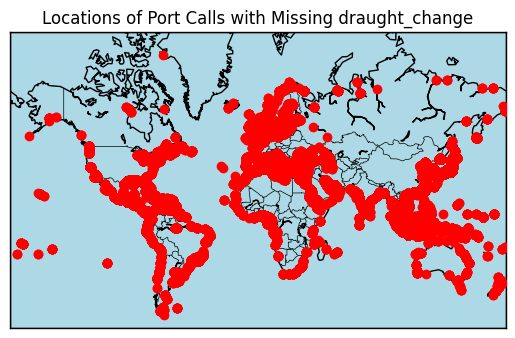

In [66]:
# Worth Plotting these too
missing_draught_change_map = Basemap(
    projection="merc",
    llcrnrlat=-60,
    urcrnrlat=80,
    llcrnrlon=-180,
    urcrnrlon=180,
    resolution="c",
)
missing_draught_change_map.drawcoastlines()
missing_draught_change_map.drawcountries()
missing_draught_change_map.drawmapboundary(fill_color="lightblue")
x, y = missing_draught_change_map(
    missing_draught_change["destination_longitude"].values,
    missing_draught_change["destination_latitude"].values,
)
missing_draught_change_map.scatter(x, y, marker="o", color="red", zorder=5)
plt.title("Locations of Port Calls with Missing draught_change")
plt.show()

These are well distributed, and a missing 'draught_change' isn't the worst field to be missing

In [67]:
# Assuming Missing values for 'destination_longitude' and 'destination_latitude' appear as a pair
missing_location = port_calls[
    port_calls["destination_longitude"].isnull()
    & port_calls["destination_latitude"].isnull()
]
len(missing_location)

1018

This confirms that they always occur as a pair

Given we are never missing a destination (str) we can look for any similarities

In [68]:
locations = missing_location.destination.value_counts()
locations.head(10)

destination
Iran                                 870
Offshore Venezuela (West of Suez)     41
Philippines                           20
Offshore Middle East Gulf             20
North East Atlantic Ocean             18
China                                  4
Malaysia                               4
Asia                                   3
Russian Federation                     3
Vietnam                                2
Name: count, dtype: int64

Most of the points within this being made up by Iran makes sense, vessels may turn off/spoff AIS information or it could be that data gathering in the region is hard

The two offshore destinations, and the North East Atlantic Ocean missing values could be explained by those regions being too large to assign single lat,long pairs to.

The overarching theme with these destinations, compared to the normal is the lack of specific port names or locations, instead defaulting to using more generic locations


#### Vessels

In [69]:
print("Missing values in vessels:")
vessels.isnull().sum()

Missing values in vessels:


id                 0
status             0
status_detail      0
build_country    114
build_year         1
flag_name         25
dead_weight        0
vessel_type        0
dtype: int64

~1.6% of vessels have missing information

In [70]:
# Starting with build country
missing_build_country = vessels[vessels["build_country"].isnull()]
missing_build_country

,id,status,status_detail,build_country,build_year,flag_name,dead_weight,vessel_type
6,118651,Active,In Service/Commission,NaN,2021.0,NaN,7356,Chemical/Oil Products Tanker
30,59155,Active,In Service/Commission,NaN,1979.0,United States of America,352,Crude/Oil Products Tanker
43,116991,Active,In Service/Commission,NaN,1998.0,Japan,1417,Asphalt/Bitumen Tanker
44,116996,Active,In Service/Commission,NaN,2013.0,China Peoples's Republic,3200,Asphalt/Bitumen Tanker
55,116979,Active,In Service/Commission,NaN,1995.0,Indonesia,1354,Asphalt/Bitumen Tanker
...,...,...,...,...,...,...,...,...
5221,82053,Active,In Service/Commission,NaN,2010.0,United States of America,1584,Crude/Oil Products Tanker
5241,88370,Active,In Service/Commission,NaN,2010.0,United States of America,428,Crude/Oil Products Tanker
5300,119517,Active,In Service/Commission,NaN,2021.0,Turkey,6043,Chemical/Oil Products Tanker
5312,63637,Active,In Service/Commission,NaN,2004.0,United States of America,334,Crude/Oil Products Tanker


A lot of these vessels seem to be missing a flag too - Worth totalling these to see if all our missing values come from these 114 vessels

In [71]:
missing_build_country.isnull().sum()

id                 0
status             0
status_detail      0
build_country    114
build_year         1
flag_name         16
dead_weight        0
vessel_type        0
dtype: int64

Most of them are in this subset but there are 9 vessels not within this set

In [77]:
# They are
remaining_vessels = vessels[~vessels.id.isin(missing_build_country.id)]
remaining_missing_flag = remaining_vessels[remaining_vessels["flag_name"].isnull()]
remaining_missing_flag

,id,status,status_detail,build_country,build_year,flag_name,dead_weight,vessel_type
1148,116686,Active,In Service/Commission,China,2007.0,NaN,4400,Asphalt/Bitumen Tanker
1521,116613,Active,In Service/Commission,South Korea,2020.0,NaN,25039,Chemical/Oil Products Tanker
3001,118616,Active,In Service/Commission,China,2021.0,NaN,5500,Chemical/Oil Products Tanker
3652,118485,Active,In Service/Commission,Japan,2023.0,NaN,26300,Chemical/Oil Products Tanker
4755,117178,Active,In Service/Commission,Japan,2022.0,NaN,25160,Chemical/Oil Products Tanker
5299,117205,Active,In Service/Commission,Japan,2022.0,NaN,25151,Chemical/Oil Products Tanker
6480,117065,Active,In Service/Commission,South Korea,2020.0,NaN,25039,Chemical/Oil Products Tanker
8089,111770,Active,In Service/Commission,Japan,2019.0,NaN,12629,Products Tanker
8868,117211,Active,In Service/Commission,South Korea,2021.0,NaN,25628,Chemical/Oil Products Tanker


These remaining 9 all were built in East Asia which is a little odd - Would have expected these to vary across the world

#### Trades

In [86]:
print("Missing values in trades:")
trades.isnull().sum()

Missing values in trades:


id                             0
port_call_origin_id            0
port_call_destination_id    1358
traded_volume                  0
distance                    3111
start_date_time                0
end_date_time                237
product                        0
product_family                 0
dtype: int64

In [87]:
# Look at port call destination id
missing_port_call_destination = trades[trades["port_call_destination_id"].isnull()]
missing_port_call_destination

,id,port_call_origin_id,port_call_destination_id,traded_volume,distance,start_date_time,end_date_time,product,product_family
740,19923254,367120647,NaN,2119.0,NaN,2023-01-11 07:20:00,2023-02-08 21:05:28,gasoil,clean petroleum products
840,17974285,368275413,NaN,35.0,NaN,2023-05-11 16:07:00,2023-06-07 03:28:00,gasoline,clean petroleum products
946,19637945,370907549,NaN,246.0,NaN,2023-11-29 22:30:00,2023-12-25 04:01:00,naphtha,clean petroleum products
1378,20503420,370303586,NaN,2.0,NaN,2023-10-10 04:15:45,2023-11-25 08:26:54,bitumen/asphalt,dirty petroleum products
1484,16469700,367263337,NaN,7426.0,NaN,2023-01-30 18:58:00,2023-02-20 19:38:04,gasoline,clean petroleum products
...,...,...,...,...,...,...,...,...,...
239293,20687172,366808757,NaN,5856.0,NaN,2023-01-01 14:00:05,2023-01-06 21:38:13,chem/bio,chem/bio
239588,19133812,369994458,NaN,251.0,NaN,2023-09-14 22:07:51,2023-10-18 22:03:04,benzene,chem/bio
239901,20696975,370282630,NaN,5419.0,NaN,2023-10-09 13:15:00,2023-12-30 00:00:00,gasoil,clean petroleum products
239904,18331210,369241776,NaN,326562.0,NaN,2023-06-15 00:00:00,NaT,iran,crude oil/condensate


These all seem to be missing their distance too. But, all these rows have a corresponding port call, and you can trace some of them through

for example:


| id | vessel_id | start_utc | end_utc | cargo_volume | draught_change | destination | destination_longitude | destination_latitude |
|---|---|---|---|---|---|---|---|---|
| 370869141 | 114417 | 2023-11-29 12:33:51.000 | 2023-11-30 12:34:41.000 | 9668 | 0.3 | Point Lisas | -61.540679 | 10.314636 |
| 370924890 | 114417 | 2023-12-04 12:18:31.000 | 2023-12-04 13:07:40.000 | 6848 | -0.7 | Georgetown (Guyana) | -58.174022 | 6.805205 |
| 371094312 | 114417 | 2023-12-13 00:08:03.000 | 2023-12-14 11:35:44.000 | 3707 | -0.8 | Saint Vincent Port | -61.212204 | 13.133713 |

Looks like this vessel trades a lot between these ports but the suggested trading volume is only 76 (There is no port call in 2024 so potentially something else going on)


Another example that stands out is the traded volume 1

| id | vessel_id | start_utc | end_utc | cargo_volume | draught_change | destination | destination_longitude | destination_latitude |
|---|---|---|---|---|---|---|---|---|
| 370810857 | 78098 | 2023-11-20 16:15:24.000 | 2023-11-22 12:54:07.000 | 42688 | 3.4 | Lalang | 102.218909 | 1.088395 |
| 370635027 | 78098 | 2023-11-23 19:16:20.000 | 2023-11-25 02:38:06.000 | 1 | -3.4 | Singapore | 103.745613 | 1.234135 |

There is already a trade starting at this port and ending at port 370635027 with a traded volume of 42687

This may indicate duplicate trades




| id | vessel_id | start_utc | end_utc | cargo_volume | draught_change | destination | destination_longitude | destination_latitude |
|---|---|---|---|---|---|---|---|---|
| 370869141 | 114417 | 2023-11-29 12:33:51.000 | 2023-11-30 12:34:41.000 | 9668 | 0.3 | Point Lisas | -61.540679 | 10.314636 |
| 370924890 | 114417 | 2023-12-04 12:18:31.000 | 2023-12-04 13:07:40.000 | 6848 | -0.7 | Georgetown (Guyana) | -58.174022 | 6.805205 |
| 371094312 | 114417 | 2023-12-13 00:08:03.000 | 2023-12-14 11:35:44.000 | 3707 | -0.8 | Saint Vincent Port | -61.212204 | 13.133713 |
| 370810857 | 78098 | 2023-11-20 16:15:24.000 | 2023-11-22 12:54:07.000 | 42688 | 3.4 | Lalang | 102.218909 | 1.088395 |
| 370635027 | 78098 | 2023-11-23 19:16:20.000 | 2023-11-25 02:38:06.000 | 1 | -3.4 | Singapore | 103.745613 | 1.234135 |

In [88]:
# Duplicate Trades can be confirmed by iterating through
# all caught ids and checking for another trade with the same starting id and dates
cols_to_match_on = ["start_date_time", "end_date_time", "product", "product_family"]
matches = 0
for _, row in missing_port_call_destination.iterrows():
    matched_rows = trades[trades["port_call_origin_id"] == row["port_call_origin_id"]]
    if len(matched_rows) > 1:  # Dont just count rows with no matches
        if all(matched_rows[cols_to_match_on] == row[cols_to_match_on]):
            matches += 1

print(matches)

1007


Only now 351 unmatched rows - This is an acceptable number to drop

In [90]:
remaining_trades = trades[~trades["id"].isin(missing_port_call_destination.id)]
remaining_trades.isnull().sum()

id                             0
port_call_origin_id            0
port_call_destination_id       0
traded_volume                  0
distance                    1753
start_date_time                0
end_date_time                  0
product                        0
product_family                 0
dtype: int64

All the missing end times were in the unmatched columns

In [93]:
missing_dist = remaining_trades[remaining_trades["distance"].isnull()]
missing_dist

,id,port_call_origin_id,port_call_destination_id,traded_volume,distance,start_date_time,end_date_time,product,product_family
78,19297550,370528898,370695047.0,11670.0,NaN,2023-11-02 05:30:01,2023-11-12 20:37:28,chem/bio,chem/bio
98,19843053,368356433,368981739.0,8938.0,NaN,2023-05-16 01:09:04,2023-06-26 08:07:45,chem/bio,chem/bio
146,16351700,367042236,367189510.0,3995.0,NaN,2023-01-08 19:34:35,2023-01-18 07:03:39,clean petroleum products,clean petroleum products
547,16959984,367645765,367748317.0,38156.0,NaN,2023-02-26 00:00:00,2023-03-06 00:00:00,vacuum gasoil,dirty petroleum products
548,16959984,367645765,367748317.0,23849.0,NaN,2023-02-26 00:00:00,2023-03-06 00:00:00,leona,crude oil/condensate
...,...,...,...,...,...,...,...,...,...
239568,17760010,368401027,368677058.0,3726.0,NaN,2023-05-18 01:15:45,2023-06-06 05:05:36,chem/bio,chem/bio
239569,17868946,368562260,368677058.0,3725.0,NaN,2023-05-29 20:30:11,2023-06-06 05:05:36,chem/bio,chem/bio
239570,17789453,368444200,368677058.0,3726.0,NaN,2023-05-21 10:05:42,2023-06-06 05:05:36,chem/bio,chem/bio
239704,17603578,368069162,368221876.0,2826.0,NaN,2023-04-21 11:31:30,2023-05-02 13:06:13,chem/bio,chem/bio


In [ ]:
# Worth checking these destination ids for an id in the portcalls
existing_calls = 0
for _, row in missing_dist.iterrows():
    id = row["port_call_destination_id"]
    if id in port_calls.id:
        existing_calls += 1

print(existing_calls)

0


All these trades dont have a port call associated with them - This makes them seem invalid and so should be dropped unless further explanation can be found

In [ ]:
# Checking Start and end dates
# Only need to check port calls and trades
if any(port_calls["end_utc"] - port_calls["start_utc"]) < 0:
    print("misaligned port call")

if any(trades["end_date_time"] - trades["start_date_time"]) < 0:
    print("misaligned trade")

# < 0 as some maybe recorded as taking 0 time
# (this isn't an issue as we only really care that they were there for a positive amount of time)